# VGW Spectrum Interpolation with JAX

This notebook is the JAX twin of `interpolate_vgw_spectrum.ipynb`. It loads the same NPZ archive, uses the same inputs and perturbative checks, and returns the same spectrum components. The interpolation core uses `jax.numpy`, is JIT-compilable, and is differentiable with respect to the continuous inputs. Plotting intentionally uses the same NumPy/Matplotlib code and visual settings as the reference notebook.

In [ ]:
from pathlib import Path
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

jax.config.update('jax_enable_x64', True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Latin Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.linewidth': 1.2,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

# Calculation inputs: modify these values for a new evaluation.
NPZ_PATH = Path('VGW_output.npz')
# NPZ_PATH = Path('rectified_smooth_VGW_output.npz')
# NPZ_PATH = Path('rectified_VGW_output.npz')
frequencies = np.logspace(-6, 4, 500)  # Hz
f_peak = 10  # Hz
n2 = 0.1

# Logarithmic parameters controlling the normalization of each contribution.
log10_A_zeta = np.log10(0.03)
log10_f_NL = 1
log10_tau_NL = np.log10(20)
log10_tilde_tau_NL = np.log10(20)
F_PEAK_REFERENCE = 1.0  # Hz, convention used when building the archive

In [27]:
archive = np.load(NPZ_PATH)
f_grid = np.asarray(archive['f_grid'], dtype=float)
n2_grid = np.asarray(archive['n2_grid'], dtype=float)
component_names = (
    'Gaussian',
    r'$f_{\rm NL}^2$',
    r'$\tau_{\rm NL}$',
    r'$\tilde{\tau}_{\rm NL}$',
)
components = {
    'Gaussian': np.asarray(archive['omega_gauss'], dtype=float),
    r'$f_{\rm NL}^2$': np.asarray(archive['omega_fnl'], dtype=float),
    r'$\tau_{\rm NL}$': np.asarray(archive['omega_taunl'], dtype=float),
    r'$\tilde{\tau}_{\rm NL}$': np.asarray(archive['omega_tildetaunl'], dtype=float),
}

if f_grid.ndim != 1 or n2_grid.ndim != 1:
    raise ValueError('f_grid and n2_grid must be one-dimensional arrays')
if any(values.shape != (len(n2_grid), len(f_grid)) for values in components.values()):
    raise ValueError('The spectrum matrices do not have the expected shape')
if np.any(f_grid <= 0) or np.any(n2_grid <= 0):
    raise ValueError('The grids must contain positive values')

# Static preprocessing: all logarithms, signs, and IR/UV slopes are computed once.
component_values = np.stack([components[name] for name in component_names])
if np.any(component_values == 0):
    raise ValueError('Logarithmic interpolation requires nonzero values')
component_signs = np.sign(component_values[:, 0, 0])
if not np.all(np.sign(component_values) == component_signs[:, None, None]):
    raise ValueError('A component changes sign: log|Omega| cannot be used')

log_f_grid = np.log10(f_grid)
log_component_values = np.log10(np.abs(component_values))

def endpoint_slope(log_x, log_y):
    """Estimate a log-log power-law slope from the endpoint region.

    Parameters
    ----------
    log_x : array-like
        Logarithmic independent-variable coordinates.
    log_y : array-like
        Logarithmic dependent-variable values; the last axis matches
        ``log_x``.

    Returns
    -------
    numpy.ndarray
        Least-squares slope for every leading dimension of ``log_y``.
    """
    x_centered = log_x - np.mean(log_x)
    y_centered = log_y - np.mean(log_y, axis=-1, keepdims=True)
    return np.sum(x_centered * y_centered, axis=-1) / np.sum(x_centered ** 2)

uv_start = max(0, len(log_f_grid) - 12)
ir_slopes = endpoint_slope(log_f_grid[:3], log_component_values[:, :, :3])
uv_slopes = endpoint_slope(log_f_grid[uv_start:], log_component_values[:, :, uv_start:])

# JAX constants used by the compiled core.
jax_log_f_grid = jnp.asarray(log_f_grid, dtype=jnp.float64)
jax_n2_grid = jnp.asarray(n2_grid, dtype=jnp.float64)
jax_log_component_values = jnp.asarray(log_component_values, dtype=jnp.float64)
jax_component_signs = jnp.asarray(component_signs, dtype=jnp.float64)
jax_ir_slopes = jnp.asarray(ir_slopes, dtype=jnp.float64)
jax_uv_slopes = jnp.asarray(uv_slopes, dtype=jnp.float64)
jax_uv_log_f_start = jnp.asarray(log_f_grid[uv_start], dtype=jnp.float64)
jax_uv_log_values_start = jnp.asarray(log_component_values[:, :, uv_start], dtype=jnp.float64)

print('f grid:', f_grid.shape, f_grid[0], f_grid[-1], 'Hz')
print('n2 grid:', n2_grid)
print('preprocessed component tensor:', component_values.shape)

f grid: (100,) 1.9069165947591904e-05 15500.0 Hz
n2 grid: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.  ]
preprocessed component tensor: (4, 19, 100)


In [28]:
def _interpolate_component_jax(
    log_values, ir_slopes, uv_slopes, uv_log_values_start,
    target_frequencies, target_f_peak, target_n2
):
    """Interpolate one spectral component on frequency and ``n2`` grids.

    Parameters
    ----------
    log_values : jax.Array
        Logarithm of the absolute component values on the archive grid.
    ir_slopes, uv_slopes : jax.Array
        Power-law slopes used for infrared and ultraviolet extrapolation.
    uv_log_values_start : jax.Array
        Logarithmic values at the start of the ultraviolet extrapolation.
    target_frequencies : jax.Array
        Frequencies, in Hz, where the component is evaluated.
    target_f_peak : float
        Target peak frequency, in Hz, used to rescale the archive frequency grid.
    target_n2 : float
        Target value of the spectral parameter ``n2``.

    Returns
    -------
    jax.Array
        Interpolated signed component values with shape ``(n_frequency,)``.
    """
    log_target_f = jnp.log10(
        target_frequencies / target_f_peak * F_PEAK_REFERENCE
    )

    def interpolate_at_n2(log_values_at_n2):
        """Interpolate one fixed-``n2`` spectrum in logarithmic frequency."""
        return jnp.interp(log_target_f, jax_log_f_grid, log_values_at_n2)

    log_value_by_n2 = jax.vmap(interpolate_at_n2)(log_values)
    ir_value = log_values[:, 0, None] + ir_slopes[:, None] * (
        log_target_f[None, :] - jax_log_f_grid[0]
    )
    uv_value = uv_log_values_start[:, None] + uv_slopes[:, None] * (
        log_target_f[None, :] - jax_uv_log_f_start
    )
    log_value_by_n2 = jnp.where(
        log_target_f[None, :] < jax_log_f_grid[0],
        ir_value,
        log_value_by_n2,
    )
    log_value_by_n2 = jnp.where(
        log_target_f[None, :] >= jax_uv_log_f_start,
        uv_value,
        log_value_by_n2,
    )
    return jax.vmap(
        lambda values_at_frequency: jnp.interp(
            target_n2, jax_n2_grid, values_at_frequency
        )
    )(log_value_by_n2.T)


def validate_perturbative_parameters(
    log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL
):
    """Check the perturbative validity conditions for nonlinear parameters.

    Parameters
    ----------
    log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL : float
        Base-10 logarithms of the scalar amplitude and non-Gaussianity
        parameters.

    Raises
    ------
    ValueError
        If any nonlinear combination with ``A_zeta**3`` is greater than or
        equal to one.
    """
    A_zeta = 10.0 ** log10_A_zeta
    f_NL = 10.0 ** log10_f_NL
    tau_NL = 10.0 ** log10_tau_NL
    tilde_tau_NL = 10.0 ** log10_tilde_tau_NL
    perturbative_products = {
        'f_NL^2 * A_zeta^3': f_NL ** 2 * A_zeta ** 3,
        'tau_NL * A_zeta^3': tau_NL * A_zeta ** 3,
        'tilde_tau_NL * A_zeta^3': tilde_tau_NL * A_zeta ** 3,
    }
    violated = {
        name: value
        for name, value in perturbative_products.items()
        if value >= 1.0
    }
    if violated:
        details = ', '.join(
            f'{name}={value:.6g}' for name, value in violated.items()
        )
        raise ValueError(
            'Perturbative validity conditions require each nonlinear product to be < 1; '
            f'violated: {details}'
        )


def _interpolate_shape_unchecked(target_frequencies, target_f_peak, target_n2):
    """Interpolate all four unnormalised spectrum components.

    Parameters
    ----------
    target_frequencies : jax.Array
        Frequencies, in Hz, where the spectrum is evaluated.
    target_f_peak : float
        Target peak frequency, in Hz.
    target_n2 : float
        Target value of the spectral parameter ``n2``.

    Returns
    -------
    jax.Array
        Component shapes with dimensions ``(4, n_frequency)`` before
        perturbative amplitude normalisation.
    """
    log_components = jax.vmap(
        _interpolate_component_jax,
        in_axes=(0, 0, 0, 0, None, None, None),
    )(
        jax_log_component_values,
        jax_ir_slopes,
        jax_uv_slopes,
        jax_uv_log_values_start,
        target_frequencies,
        target_f_peak,
        target_n2,
    )
    return jax_component_signs[:, None] * 10.0 ** log_components


def _normalization_factors_unchecked(
    log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL
):
    """Compute the perturbative prefactor for each spectrum component.

    Parameters
    ----------
    log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL : float
        Base-10 logarithms of the scalar amplitude and non-Gaussianity
        parameters.

    Returns
    -------
    jax.Array
        Four normalisation factors for the Gaussian, $f_NL^2$, $tau_NL$,
        and $tilde{tau}_NL$ components.
    """
    A_zeta = 10.0 ** log10_A_zeta
    f_NL = 10.0 ** log10_f_NL
    tau_NL = 10.0 ** log10_tau_NL
    tilde_tau_NL = 10.0 ** log10_tilde_tau_NL
    return jnp.stack([
        A_zeta ** 2,
        A_zeta ** 3 * f_NL ** 2,
        A_zeta ** 3 * tau_NL,
        A_zeta ** 3 * tilde_tau_NL,
    ])


def _normalize_shape_unchecked(
    shape, log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL
):
    """Apply perturbative normalisation factors to interpolated shapes.

    Parameters
    ----------
    shape : jax.Array
        Unnormalised component shapes with dimensions ``(4, n_frequency)``.
    log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL : float
        Base-10 logarithms of the physical amplitude parameters.

    Returns
    -------
    jax.Array
        Normalised spectrum components with the same shape as ``shape``.
    """
    return shape * _normalization_factors_unchecked(
        log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL
    )[:, None]


interpolate_shape_jit = jax.jit(_interpolate_shape_unchecked)
normalize_spectrum_jit = jax.jit(_normalize_shape_unchecked)
interpolate_shape_batch_jit = jax.jit(
    jax.vmap(_interpolate_shape_unchecked, in_axes=(None, 0, 0))
)


def _spectrum_from_values(target_frequencies, values):
    """Package component arrays and their total into the public result format.

    Parameters
    ----------
    target_frequencies : array-like
        Frequencies, in Hz, associated with the spectrum values.
    values : array-like
        Component array with shape ``(4, n_frequency)``.

    Returns
    -------
    dict
        Dictionary containing ``f`` and the component spectra under
        ``h2Omega``; the total is the sum of the first three components.
    """
    total = values[0] + values[1] + values[2]
    return {
        'f': target_frequencies,
        'h2Omega': {
            component_names[0]: values[0],
            component_names[1]: values[1],
            component_names[2]: values[2],
            component_names[3]: values[3],
            'total': total,
        },
    }


def interpolate_spectrum_jax(
    target_frequencies,
    target_f_peak=1.0,
    target_n2=0.50,
    log10_A_zeta=0.0,
    log10_f_NL=0.0,
    log10_tau_NL=0.0,
    log10_tilde_tau_NL=0.0,
):
    """Evaluate the complete normalised VGW spectrum with JAX.

    Parameters
    ----------
    target_frequencies : array-like
        Positive frequencies, in Hz, where the spectrum is required.
    target_f_peak : float, optional
        Peak frequency in Hz used to rescale the tabulated spectrum.
    target_n2 : float, optional
        Spectral parameter, constrained to the tabulated ``n2`` range.
    log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL : float, optional
        Base-10 logarithms of the scalar amplitude and non-Gaussianity
        parameters.

    Returns
    -------
    dict
        Frequencies and four component spectra in ``h2Omega``, plus their
        total (the sum of the first three components).

    Raises
    ------
    ValueError
        If frequencies, ``target_f_peak``, ``target_n2`` or the perturbative
        validity conditions are outside their allowed ranges.
    """
    target_frequencies = jnp.asarray(target_frequencies, dtype=jnp.float64)
    if target_frequencies.ndim != 1 or np.any(np.asarray(target_frequencies) <= 0):
        raise ValueError('Frequencies must be a one-dimensional array of positive values')
    if target_f_peak <= 0:
        raise ValueError('f_peak must be positive')
    if not n2_grid[0] <= target_n2 <= n2_grid[-1]:
        raise ValueError(f'n2 must belong to [{n2_grid[0]}, {n2_grid[-1]}]')
    validate_perturbative_parameters(
        log10_A_zeta, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL
    )
    shape = interpolate_shape_jit(target_frequencies, target_f_peak, target_n2)
    values = normalize_spectrum_jit(
        shape,
        log10_A_zeta,
        log10_f_NL,
        log10_tau_NL,
        log10_tilde_tau_NL,
    )
    return _spectrum_from_values(target_frequencies, values)

In [29]:
jax_frequencies = jnp.asarray(frequencies, dtype=jnp.float64)

# Interpolate the shape once. Amplitude-only changes can reuse this array.
shape = interpolate_shape_jit(jax_frequencies, f_peak, n2)
values = normalize_spectrum_jit(
    shape,
    log10_A_zeta,
    log10_f_NL,
    log10_tau_NL,
    log10_tilde_tau_NL,
)
spectrum = _spectrum_from_values(jax_frequencies, values)

result_table = np.column_stack([
    np.asarray(spectrum['f']),
    *(np.asarray(spectrum['h2Omega'][name]) for name in component_names),
    np.asarray(spectrum['h2Omega']['total']),
])
print(r'columns: f, Gaussian, IGW2, IGW3, VGW, total')
print(result_table)

# Differentiation through the normalization while reusing the interpolated shape.
gradient = jax.grad(lambda log_a: jnp.sum(
    normalize_spectrum_jit(
        shape, log_a, log10_f_NL, log10_tau_NL, log10_tilde_tau_NL
    )[:3]
))(log10_A_zeta)
print('d(sum(total))/d(log10_A_zeta) =', gradient)

# Batch evaluation for many inference points sharing the same frequency array.
f_peak_batch = jnp.asarray([0.05, 0.1, 0.2], dtype=jnp.float64)
n2_batch = jnp.asarray([0.2, 0.3, 0.4], dtype=jnp.float64)
shape_batch = interpolate_shape_batch_jit(jax_frequencies, f_peak_batch, n2_batch)
print('batch shape:', shape_batch.shape)
print('batch points:', len(f_peak_batch))

columns: f, Gaussian, IGW2, IGW3, VGW, total
[[ 1.00000000e-06  3.03103706e-28  4.12940738e-29  2.47081961e-31
  -5.65923824e-38  3.44644862e-28]
 [ 1.04722519e-06  3.50944392e-28  4.79659163e-29  2.93144622e-31
  -7.08587594e-38  3.99203453e-28]
 [ 1.09668060e-06  4.06336061e-28  5.57157217e-29  3.47794590e-31
  -8.87215482e-38  4.62399577e-28]
 ...
 [ 9.11842520e+03  1.74416334e-09  3.03876616e-09  2.32802101e-09
  -2.04761022e-10  7.11095052e-09]
 [ 9.54904456e+03  1.72855534e-09  2.99698975e-09  2.29601580e-09
  -2.02211672e-10  7.02156089e-09]
 [ 1.00000000e+04  1.71308700e-09  2.95578768e-09  2.26445058e-09
  -1.99694062e-10  6.93332526e-09]]
d(sum(total))/d(log10_A_zeta) = 1.4468935206475933e-05
batch shape: (3, 4, 500)
batch points: 3


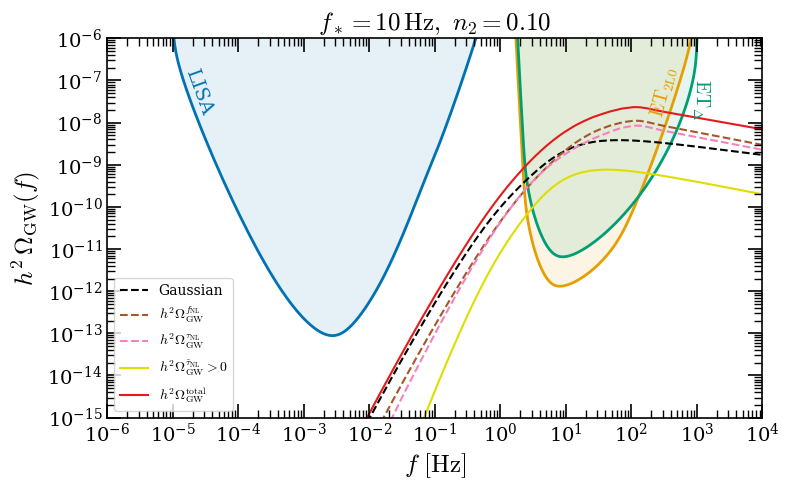

Saved plot to interpolated_Omega_GW_10_0.10_jax.pdf


In [30]:
LISA = np.loadtxt('LISA_4yr_SNR10.txt')
ET2L = np.loadtxt('ET_2L0_1yr_SNR10.txt')
ETD = np.loadtxt('ET_Tr_1yr_SNR10.txt')
LISA_color = (0 / 255, 114 / 255, 178 / 255)
ET2L_color = (230 / 255, 159 / 255, 0 / 255)
ETD_color = (0 / 255, 158 / 255, 115 / 255)

def positive_plot(ax, x, y, **kwargs):
    """Plot only finite positive samples on logarithmic axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes receiving the curve.
    x, y : array-like
        Coordinates of the curve; non-finite and non-positive samples are
        omitted because they cannot be displayed on log scales.
    **kwargs
        Additional style arguments passed to ``ax.loglog``.

    Returns
    -------
    None
        The curve is added directly to ``ax``.
    """
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.any(valid):
        ax.loglog(x[valid], y[valid], **kwargs)


def plot_spectrum(spectrum, target_f_peak, target_n2):
    """Create the detector-sensitivity and VGW spectrum comparison plot.

    Parameters
    ----------
    spectrum : dict
        Spectrum dictionary returned by ``_spectrum_from_values`` or
        ``interpolate_spectrum_jax``.
    target_f_peak : float
        Peak frequency in Hz, shown in the plot title.
    target_n2 : float
        Spectral parameter shown in the plot title.

    Returns
    -------
    tuple of matplotlib.figure.Figure and matplotlib.axes.Axes
        Figure and axes containing the logarithmic comparison plot.
    """
    f = np.asarray(spectrum['f'])
    y = {name: np.asarray(value) for name, value in spectrum['h2Omega'].items()}
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$f\,\,[\mathrm{Hz}]$')
    ax.set_ylabel(r'$h^2\,\Omega_{\mathrm{GW}}(f)$')
    ax.set_title(rf'$f_\ast={target_f_peak:.3g}\,\mathrm{{Hz}},\,\,n_2={target_n2:.2f}$')
    ax.grid(False)
    positive_plot(ax, LISA[:, 0], LISA[:, 1], color=LISA_color, lw=2)
    ax.fill_between(LISA[:, 0], LISA[:, 1], y2=np.max(LISA[:, 1]), color=LISA_color, alpha=0.1)
    ax.text(10 ** (-4.85), 10 ** (-7.8), 'LISA', color=LISA_color, rotation=290, fontsize=14)
    positive_plot(ax, ET2L[:, 0], ET2L[:, 1], color=ET2L_color, lw=2)
    ax.fill_between(ET2L[:, 0], ET2L[:, 1], y2=np.max(ET2L[:, 1]), color=ET2L_color, alpha=0.1)
    ax.text(10 ** 2.25, 10 ** (-7.8), r'$\rm ET_{\rm 2L0}$', color=ET2L_color, rotation=75, fontsize=14)
    positive_plot(ax, ETD[:, 0], ETD[:, 1], color=ETD_color, lw=2)
    ax.fill_between(ETD[:, 0], ETD[:, 1], y2=np.max(ETD[:, 1]), color=ETD_color, alpha=0.1)
    ax.text(10 ** 2.9, 10 ** (-7.8), r'$\rm ET_{\Delta}$', color=ETD_color, rotation=270, fontsize=14)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', width=1.2)
    positive_plot(ax, f, y['Gaussian'], color='black', linestyle='dashed', label='Gaussian')
    positive_plot(ax, f, y[r'$f_{\rm NL}^2$'], color='#a65628', linestyle='dashed', label=r'$h^2\Omega^{f_{\rm NL}}_{\rm GW}$')
    positive_plot(ax, f, y[r'$\tau_{\rm NL}$'], color='#f781bf', linestyle='dashed', label=r'$h^2\Omega^{\tau_{\rm NL}}_{\rm GW}$')
    positive_plot(ax, f, np.abs(y[r'$\tilde{\tau}_{\rm NL}$']), color='#dede00', linestyle='solid', label=r'$h^2\Omega^{\tilde{\tau}_{\rm NL}}_{\rm GW}>0$')
    positive_plot(ax, f, y['total'], color='#e41a1c', linestyle='solid', label=r'$h^2\Omega^{\rm total}_{\rm GW}$')
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=11))
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=10, width=1.2)
    ax.tick_params(which='minor', length=6, width=1.0)
    ax.legend(loc='lower left')
    ax.set_ylim(1e-15, 1e-6)
    ax.set_xlim(1.0e-6, 1.0e4)
    ax.set_axisbelow(False)
    fig.tight_layout()
    return fig, ax

fig, ax = plot_spectrum(spectrum, f_peak, n2)
PLOT_PATH = Path(f'interpolated_Omega_GW_{f_peak:g}_{n2:.2f}_jax.pdf')
fig.savefig(PLOT_PATH)
plt.show()
print(f'Saved plot to {PLOT_PATH}')